# Recuperación de Información Multimodal con CLIP

En este notebook vamos a demostrar cómo funciona la **recuperación de información multimodal**: buscar imágenes usando texto como consulta, sin que las imágenes tengan etiquetas ni descripciones.

## 1. ¿Cuál es el problema?

La recuperación de información tradicional trabaja con **texto**: documentos, páginas web, artículos. Usamos modelos como TF-IDF o BM25 para buscar palabras.

Pero, ¿qué pasa si queremos buscar una **imagen**? Por ejemplo:

> *"un perro corriendo en la playa"*

El problema es que una imagen son solo **píxeles**. Ningún píxel dice "perro" ni "playa". Esto se conoce como el **semantic gap** (brecha semántica): la representación cruda de los datos no expresa directamente su significado.

### La solución: un espacio vectorial compartido

La idea es proyectar **texto e imágenes al mismo espacio vectorial**, de forma que conceptos similares queden cerca, sin importar si vienen de texto o de imagen.

El modelo que hace esto es **CLIP** (Contrastive Language-Image Pre-training), creado por OpenAI. CLIP tiene dos encoders:
- Un **encoder de texto** (basado en Transformer)
- Un **encoder de imagen** (basado en Vision Transformer)

Ambos producen vectores en el **mismo espacio**, así que podemos comparar texto con imagen usando **similitud coseno**.

## 2. Instalación de dependencias

In [2]:
# !pip install transformers torch pillow matplotlib requests

In [26]:
# !pip install open-clip-torch

## 3. Cargar el modelo CLIP

Usamos el modelo `ViT-B/32` de OpenAI a través de la librería open_clip. Este modelo fue entrenado con **400 millones** de pares (imagen, texto) de internet.

El `tokenizer` preprocesa el texto y preprocess transforma las imágenes al formato que el modelo necesita.


 El `modelo` contiene dos encoders (texto e imagen) y produce vectores en un espacio compartido de **512** dimensiones.

In [27]:
import open_clip
import torch

modelo, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
modelo.eval()

print("Modelo CLIP cargado con open_clip")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

c:\Users\ladol\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ladol\.cache\huggingface\hub\models--timm--vit_base_patch32_clip_224.openai. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\ladol\anaconda3\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch betwe

Modelo CLIP cargado con open_clip


## 4. Preparar la colección de imágenes

Usamos una colección de 10 imágenes variadas almacenadas localmente. 

Importante: estas imágenes NO tienen etiquetas ni descripciones. Son solo archivos de imagen crudos

In [28]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import re

carpeta = "imagenes"
imagenes = {}

archivos = sorted(
    [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".jpeg", ".png"))],
    key=lambda x: int(re.search(r'\d+', x).group())
)

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    img = Image.open(ruta).convert("RGB")
    nombre = os.path.splitext(archivo)[0]
    imagenes[nombre] = img
    print(f"{nombre} cargada - tamaño: {img.size}")

img_1 cargada - tamaño: (739, 415)
img_2 cargada - tamaño: (554, 554)
img_3 cargada - tamaño: (640, 480)
img_4 cargada - tamaño: (1200, 900)
img_5 cargada - tamaño: (1170, 778)
img_6 cargada - tamaño: (1600, 900)
img_7 cargada - tamaño: (515, 388)
img_8 cargada - tamaño: (8256, 5504)
img_9 cargada - tamaño: (640, 480)
img_10 cargada - tamaño: (678, 452)


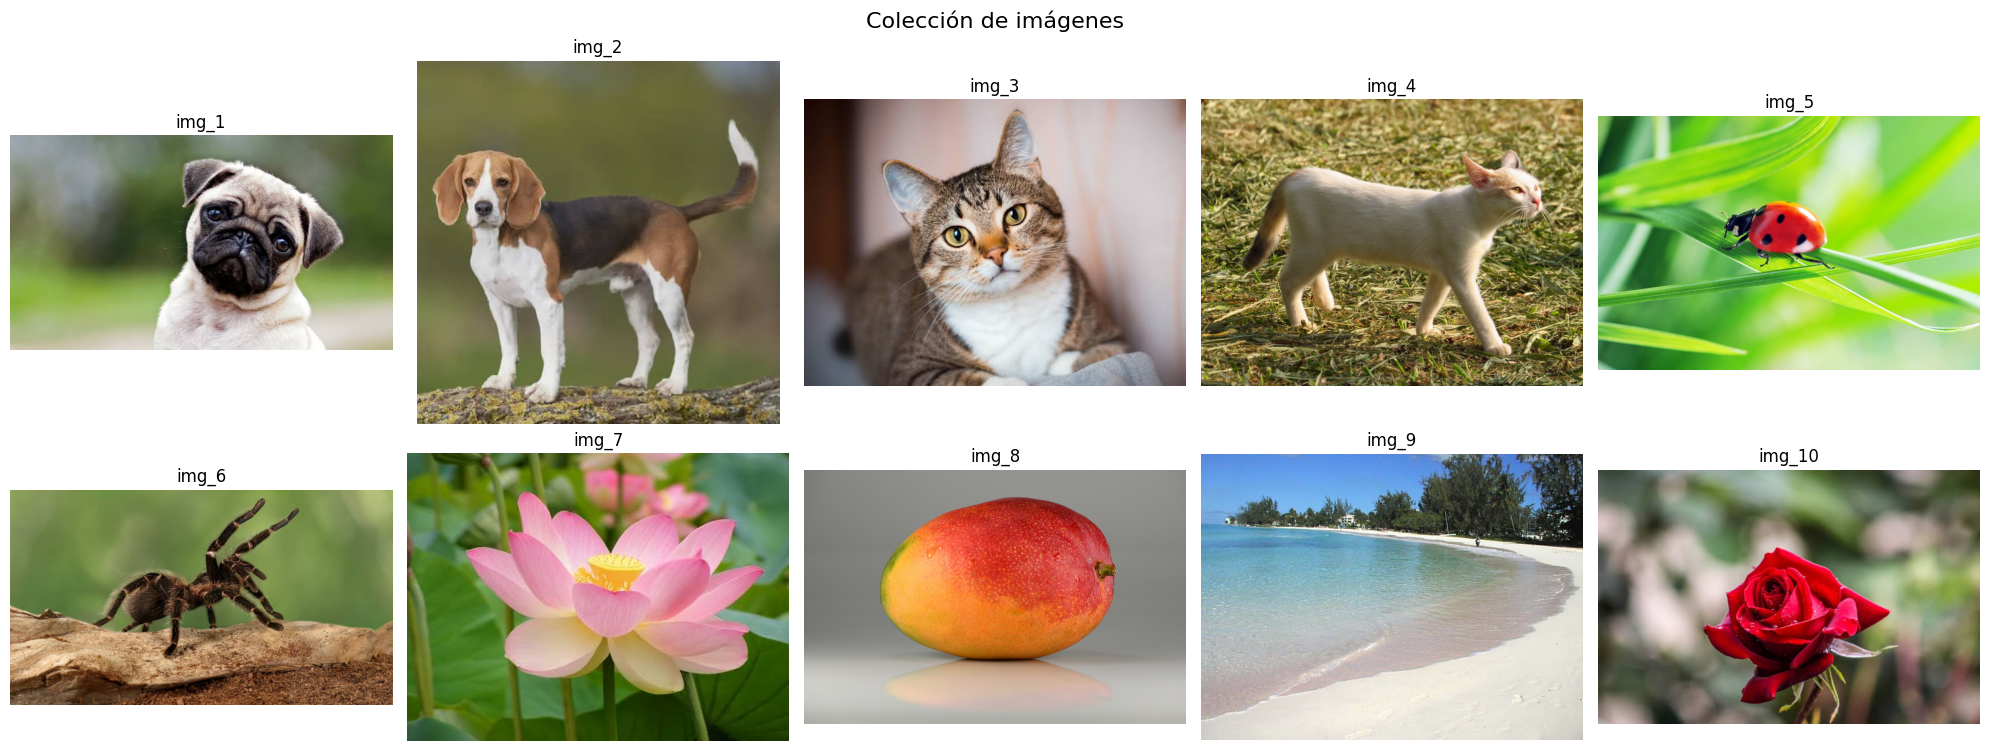

In [29]:
import math

n = len(imagenes)
cols = 5
filas = math.ceil(n / cols)

fig, axes = plt.subplots(filas, cols, figsize=(4 * cols, 4 * filas))
axes = axes.flatten()

for idx, (nombre, img) in enumerate(imagenes.items()):
    axes[idx].imshow(img)
    axes[idx].set_title(nombre, fontsize=12)
    axes[idx].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.suptitle("Colección de imágenes", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Codificar las imágenes con CLIP

Ahora pasamos cada imagen por el **encoder de imagen** de CLIP. Esto convierte cada imagen en un vector de 512 dimensiones.

Estos vectores capturan el **significado semántico** de la imagen, no los píxeles crudos. Así, una imagen de un perro tendrá un vector cercano al texto "a dog".

In [30]:
import numpy as np

embeddings_imgs = {}

with torch.no_grad():
    for nombre, img in imagenes.items():
        img_tensor = preprocess(img).unsqueeze(0)
        emb = modelo.encode_image(img_tensor)
        emb = emb / emb.norm(dim=-1, keepdim=True)
        embeddings_imgs[nombre] = emb.squeeze().numpy()

print("Imágenes codificadas.")
print(f"Forma de cada vector: {embeddings_imgs['img_1'].shape}")

Imágenes codificadas.
Forma de cada vector: (512,)


## 6. Búsqueda: texto → imágenes

Aquí está la magia de la **recuperación multimodal**:

1. Tomamos una consulta de **texto** (ej: "a dog")
2. La pasamos por el **encoder de texto** de CLIP → obtenemos un vector de 512 dims
3. Calculamos la **similitud coseno** entre ese vector y cada vector de imagen
4. Rankeamos las imágenes de mayor a menor similitud

Esto funciona porque CLIP fue entrenado para que pares (texto, imagen) relacionados tengan vectores cercanos en el espacio compartido.

In [33]:
from scipy.special import softmax

def buscar_imagenes(query, embeddings_imgs, modelo, tokenizer, imagenes, top_k=4):
    with torch.no_grad():
        tokens = tokenizer([query])
        emb_texto = modelo.encode_text(tokens)
        emb_texto = emb_texto / emb_texto.norm(dim=-1, keepdim=True)
        emb_texto = emb_texto.squeeze().numpy()
    
    # similitud coseno
    nombres = list(embeddings_imgs.keys())
    sims = np.array([np.dot(emb_texto, embeddings_imgs[n]) for n in nombres])
    
    # escalar con la temperatura de CLIP y aplicar softmax
    logit_scale = modelo.logit_scale.exp().item()
    probs = softmax(sims * logit_scale)
    
    ranking = sorted(zip(nombres, sims, probs), key=lambda x: x[1], reverse=True)
    
    print(f'Query: "{query}"\n')
    print("Ranking (similitud coseno → probabilidad):")
    for nombre, sim, prob in ranking:
        barra = "█" * int(prob * 100)
        print(f"  {nombre}: sim={sim:.4f}  prob={prob:.1%} {barra}")
    
    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for i, (nombre, sim, prob) in enumerate(ranking[:top_k]):
        axes[i].imshow(imagenes[nombre])
        axes[i].set_title(f"#{i+1} - {nombre}\nprob = {prob:.1%}", fontsize=11)
        axes[i].axis("off")
    plt.suptitle(f'Resultados para: "{query}"', fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return ranking

### Consulta 1: "a dog"

Buscamos imágenes de perros. Recordemos que las imágenes **no tienen etiquetas** — CLIP debe entender el contenido semántico de cada imagen y relacionarlo con el texto.

Query: "a dog"

Ranking (similitud coseno → probabilidad):
  img_1: sim=0.2540  prob=51.1% ███████████████████████████████████████████████████
  img_2: sim=0.2527  prob=45.2% █████████████████████████████████████████████
  img_4: sim=0.2218  prob=2.1% ██
  img_3: sim=0.2158  prob=1.1% █
  img_5: sim=0.1957  prob=0.2% 
  img_6: sim=0.1951  prob=0.1% 
  img_8: sim=0.1941  prob=0.1% 
  img_10: sim=0.1877  prob=0.1% 
  img_9: sim=0.1867  prob=0.1% 
  img_7: sim=0.1747  prob=0.0% 


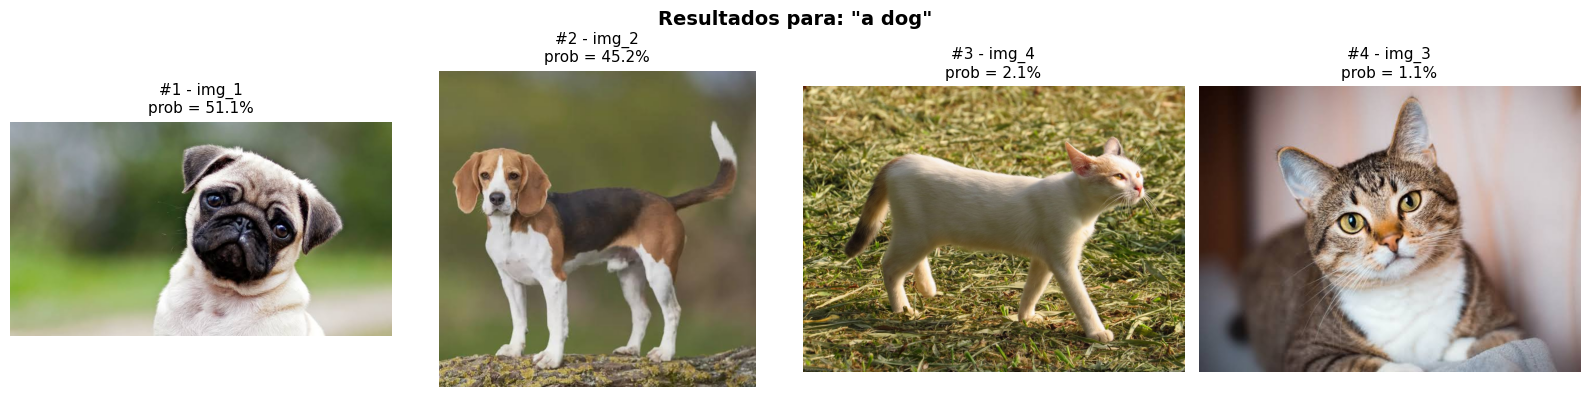

In [34]:
_ = buscar_imagenes("a dog", embeddings_imgs, modelo, tokenizer, imagenes)

### Consulta 2: "a cat sitting"

Ahora buscamos gatos. Notemos que no solo identifica la categoría (animal), sino que distingue entre perros y gatos.

Query: "a cat sitting"

Ranking (similitud coseno → probabilidad):
  img_3: sim=0.2624  prob=74.7% ██████████████████████████████████████████████████████████████████████████
  img_4: sim=0.2515  prob=25.0% ████████████████████████
  img_1: sim=0.2032  prob=0.2% 
  img_6: sim=0.1905  prob=0.1% 
  img_5: sim=0.1797  prob=0.0% 
  img_2: sim=0.1753  prob=0.0% 
  img_8: sim=0.1749  prob=0.0% 
  img_7: sim=0.1605  prob=0.0% 
  img_10: sim=0.1538  prob=0.0% 
  img_9: sim=0.1481  prob=0.0% 


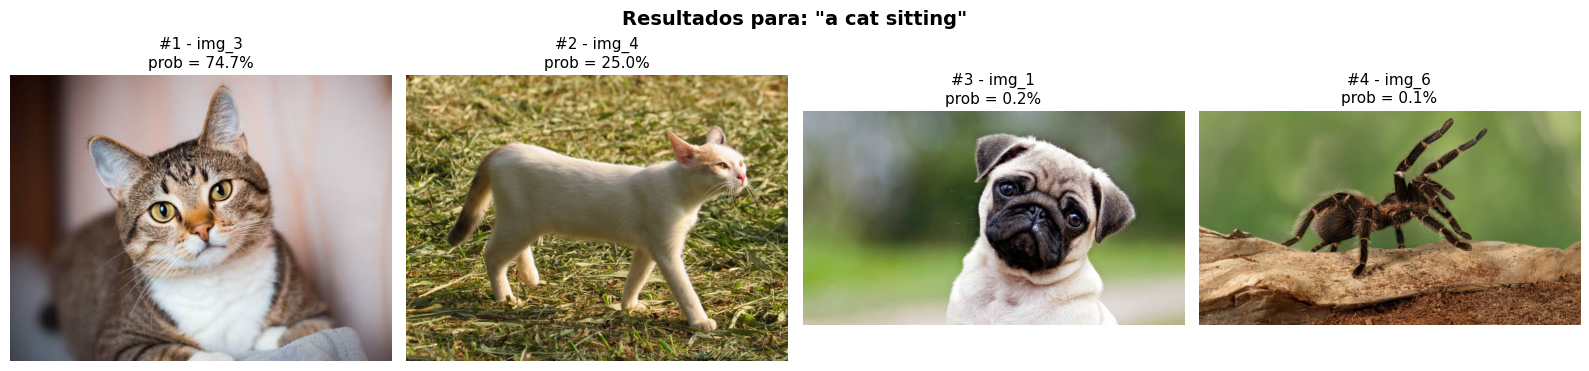

In [35]:
_ = buscar_imagenes("a cat sitting", embeddings_imgs, modelo, tokenizer, imagenes)

### Consulta 3: "a beach"

Probemos algo completamente diferente: un .

Query: "a beach"

Ranking (similitud coseno → probabilidad):
  img_9: sim=0.2811  prob=99.9% ███████████████████████████████████████████████████████████████████████████████████████████████████
  img_8: sim=0.2100  prob=0.1% 
  img_5: sim=0.1780  prob=0.0% 
  img_2: sim=0.1767  prob=0.0% 
  img_4: sim=0.1762  prob=0.0% 
  img_1: sim=0.1757  prob=0.0% 
  img_7: sim=0.1720  prob=0.0% 
  img_3: sim=0.1695  prob=0.0% 
  img_6: sim=0.1691  prob=0.0% 
  img_10: sim=0.1622  prob=0.0% 


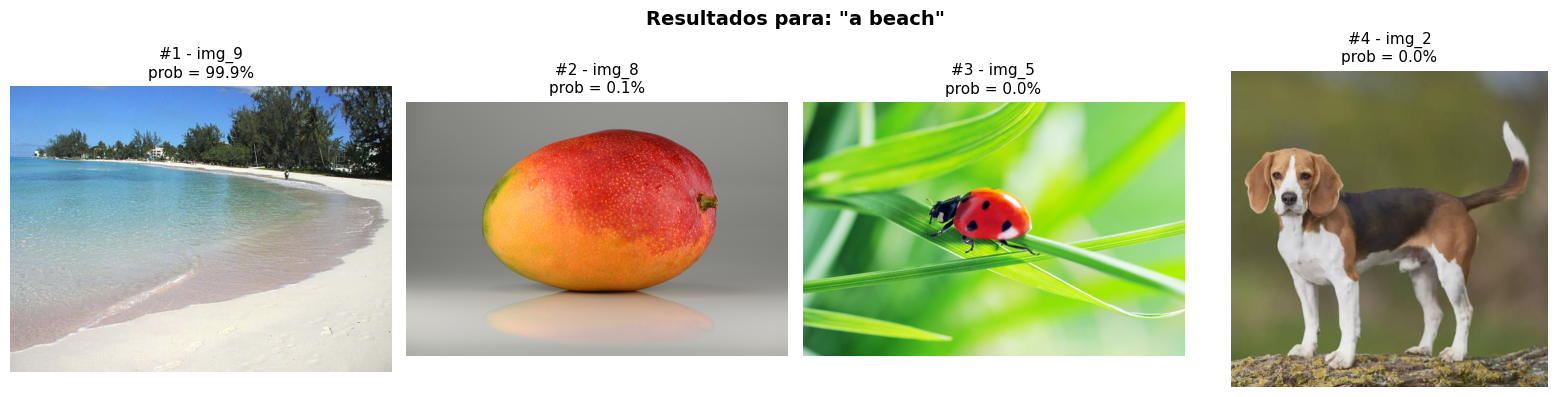

In [37]:
_ = buscar_imagenes("a beach", embeddings_imgs, modelo, tokenizer, imagenes)

### Consulta 4: "healthy food, fruits and vegetables"

Una consulta más compleja con múltiples conceptos.

Query: "healthy food, fruits and vegetables"

Ranking (similitud coseno → probabilidad):
  img_8: sim=0.2546  prob=94.9% ██████████████████████████████████████████████████████████████████████████████████████████████
  img_5: sim=0.2215  prob=3.5% ███
  img_7: sim=0.2099  prob=1.1% █
  img_10: sim=0.1984  prob=0.3% 
  img_9: sim=0.1823  prob=0.1% 
  img_4: sim=0.1776  prob=0.0% 
  img_3: sim=0.1744  prob=0.0% 
  img_1: sim=0.1740  prob=0.0% 
  img_6: sim=0.1646  prob=0.0% 
  img_2: sim=0.1631  prob=0.0% 


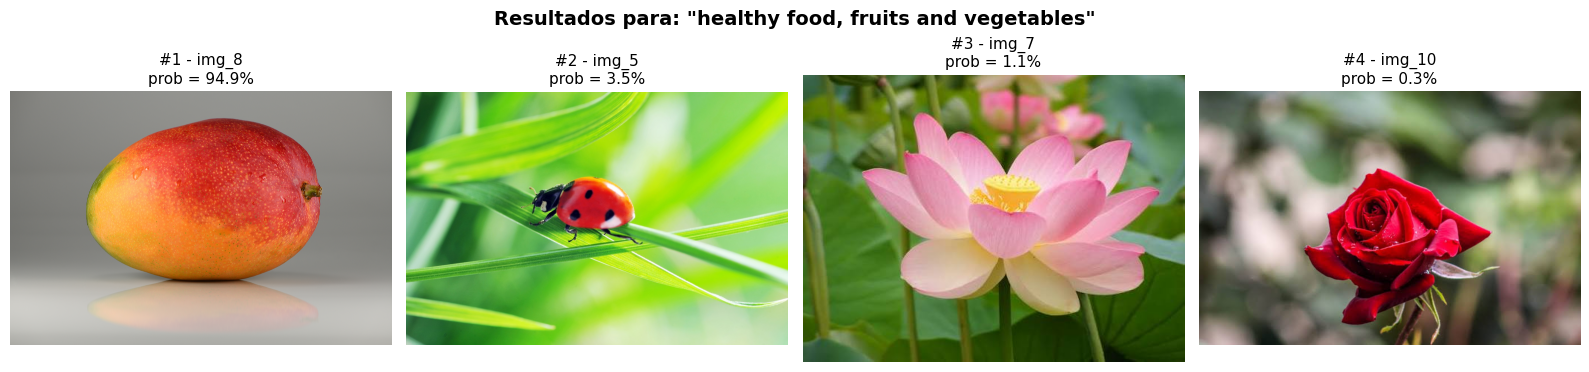

In [38]:
_ = buscar_imagenes("healthy food, fruits and vegetables", embeddings_imgs, modelo, tokenizer, imagenes)

## 7. Visualizar el espacio compartido

Para entender mejor qué hace CLIP, podemos reducir los vectores de 512 dimensiones a **2 dimensiones** usando PCA y graficar imágenes y textos juntos.

Si CLIP funciona bien, veremos que los textos quedan **cerca** de las imágenes que describen.

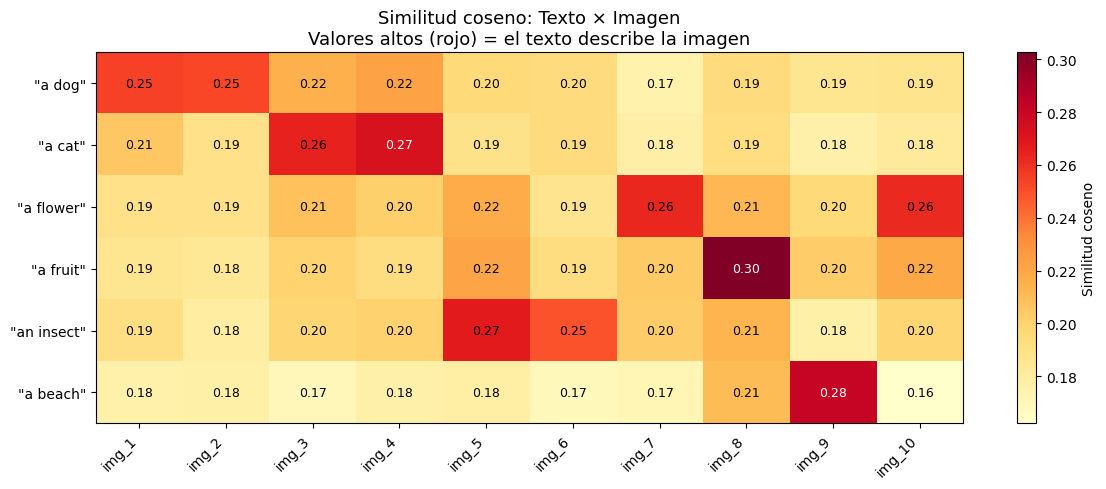

In [42]:
textos = ["a dog", "a cat", "a flower", "a fruit", "an insect", "a beach"]

embs_texto = []
with torch.no_grad():
    for t in textos:
        tokens = tokenizer([t])
        e = modelo.encode_text(tokens)
        e = e / e.norm(dim=-1, keepdim=True)
        embs_texto.append(e.squeeze().numpy())

nombres_img = list(embeddings_imgs.keys())
vectores_img = np.array([embeddings_imgs[n] for n in nombres_img])
vectores_txt = np.array(embs_texto)

# matriz de similitud: cada texto vs cada imagen
matriz_sim = vectores_txt @ vectores_img.T

plt.figure(figsize=(12, 5))
im = plt.imshow(matriz_sim, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, label="Similitud coseno")

plt.xticks(range(len(nombres_img)), nombres_img, rotation=45, ha="right")
plt.yticks(range(len(textos)), [f'"{t}"' for t in textos])

for i in range(len(textos)):
    for j in range(len(nombres_img)):
        color = "white" if matriz_sim[i, j] > 0.27 else "black"
        plt.text(j, i, f"{matriz_sim[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color=color)

plt.title("Similitud coseno: Texto × Imagen\nValores altos (rojo) = el texto describe la imagen", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Conclusión

### ¿Qué demostramos?

- La RI tradicional (TF-IDF, BM25) solo funciona con texto. Pero la información del mundo real incluye imágenes, audio, video.
- El **semantic gap** impide buscar directamente en datos no textuales: los píxeles no contienen palabras.
- La solución es un **espacio vectorial compartido**: proyectar diferentes modalidades al mismo espacio donde el significado se preserva.
- **CLIP** logra esto con dos encoders (texto e imagen) entrenados con aprendizaje contrastivo sobre 400M de pares.
- Pudimos buscar imágenes con texto, **sin etiquetas**, gracias a que CLIP comprende el contenido semántico de ambas modalidades.